# Nettoyage des données DVF - Ille-et-Vilaine (2021-2025)

Ce notebook charge les fichiers DVF bruts (un par année), les assemble, filtre les colonnes et les types de biens pertinents, traite les valeurs manquantes et aberrantes, calcule le prix au m², puis exporte un fichier propre dans `data/cleaned/`.

Source : [Demandes de valeurs foncières géolocalisées](https://www.data.gouv.fr/datasets/demandes-de-valeurs-foncieres-geolocalisees) (data.gouv.fr / DGFiP), périmètre Ille-et-Vilaine, 2021 à 2025.

## Sommaire

1. [Chargement des données](#1.-Chargement-des-données)
2. [Exploration initiale](#2.-Exploration-initiale)
3. [Filtrage sur le type de transaction](#3.-Filtrage-sur-le-type-de-transaction)
4. [Sélection des colonnes utiles](#4.-Sélection-des-colonnes-utiles)
5. [Filtrage sur le type de bien](#5.-Filtrage-sur-le-type-de-bien)
6. [Traitement des doublons de mutation](#6.-Traitement-des-doublons-de-mutation)
7. [Détection et traitement des valeurs aberrantes](#7.-Détection-et-traitement-des-valeurs-aberrantes)
8. [Vérification finale et export](#8.-Vérification-finale-et-export)

## 1. Chargement des données

In [86]:
# Bibliothèques utilisées dans tout le notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
# Chargement des 5 fichiers DVF (un par année), ajout d'une colonne "annee"
# pour garder la trace de l'origine de chaque ligne, puis assemblage en un
# seul DataFrame
annees = [2021, 2022, 2023, 2024, 2025]
dataframes = []

for annee in annees:
    chemin = f"../data/raw/dvf_35_{annee}.csv.gz"
    df_annee = pd.read_csv(chemin, low_memory=False)
    df_annee["annee"] = annee
    dataframes.append(df_annee)

df = pd.concat(dataframes, ignore_index=True)

print(df.shape)
df.head()

(337019, 41)


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,annee
0,2021-591508,2021-01-07,1,Vente,160000.0,7.0,NaN,RUE BEAUGEARD LANCELOT,0750,35700.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,-1.656551,48.119053,2021
1,2021-591508,2021-01-07,1,Vente,160000.0,7.0,NaN,RUE BEAUGEARD LANCELOT,0750,35700.0,...,55.0,3.0,NaN,NaN,NaN,NaN,NaN,-1.656551,48.119053,2021
2,2021-591509,2021-01-06,1,Vente,225000.0,6.0,NaN,BD DES METAIRIES,0432,35510.0,...,81.0,4.0,NaN,NaN,NaN,NaN,NaN,-1.599096,48.121689,2021
3,2021-591510,2021-01-07,1,Vente,304000.0,12.0,NaN,ALL EMILE GERNIGON,0963,35136.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,-1.699642,48.091458,2021
4,2021-591510,2021-01-07,1,Vente,304000.0,12.0,NaN,ALL EMILE GERNIGON,0963,35136.0,...,96.0,4.0,NaN,NaN,NaN,NaN,NaN,-1.699642,48.091458,2021


**Résultat :** 337 019 lignes et 41 colonnes pour les 5 années cumulées. Les fichiers 2021 à 2025 ont été utilisés à la place de 2020-2024 initialement prévu : le fichier 2020 par département n'est plus disponible à l'emplacement standard des DVF géolocalisées.

## 2. Exploration initiale

Avant de nettoyer, on regarde d'abord ce que contient réellement le tableau : les types de colonnes, les valeurs manquantes, et les doublons potentiels.

In [88]:
# Carte d'identité du tableau : nom des colonnes, nombre de valeurs non
# vides, type de chaque colonne
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 337019 entries, 0 to 337018
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_mutation                   337019 non-null  str    
 1   date_mutation                 337019 non-null  str    
 2   numero_disposition            337019 non-null  int64  
 3   nature_mutation               337019 non-null  str    
 4   valeur_fonciere               333524 non-null  float64
 5   adresse_numero                216238 non-null  float64
 6   adresse_suffixe               13028 non-null   str    
 7   adresse_nom_voie              332070 non-null  str    
 8   adresse_code_voie             332121 non-null  str    
 9   code_postal                   332118 non-null  float64
 10  code_commune                  337019 non-null  int64  
 11  nom_commune                   337019 non-null  str    
 12  code_departement              337019 non-null  int64  


In [89]:
# Nombre de valeurs manquantes, uniquement sur les colonnes utiles pour
# répondre aux 5 questions business du projet
colonnes_utiles = [
    "date_mutation", "annee", "nature_mutation", "valeur_fonciere",
    "surface_reelle_bati", "type_local", "code_commune", "nom_commune",
    "longitude", "latitude"
]

df[colonnes_utiles].isnull().sum()

date_mutation               0
annee                       0
nature_mutation             0
valeur_fonciere          3495
surface_reelle_bati    232562
type_local             157570
code_commune                0
nom_commune                 0
longitude                8494
latitude                 8494
dtype: int64

**Résultat :** aucune valeur manquante sur `date_mutation`, `annee`, `nature_mutation`, `code_commune`, `nom_commune`. En revanche `surface_reelle_bati` (69 %) et `type_local` (47 %) manquent sur une grande partie des lignes, à investiguer avant d'agir.

## 3. Filtrage sur le type de transaction

Hypothèse à vérifier : les valeurs manquantes sur `surface_reelle_bati` et `type_local` viennent-elles de lignes qui ne décrivent pas un logement (terrain nu, vente en l'état futur d'achèvement) ?

In [90]:
# Aperçu de la nature des transactions sur les lignes où type_local est
# manquant, pour comprendre pourquoi
df[df["type_local"].isnull()][["nature_mutation", "code_nature_culture", "nature_culture"]].head(10)

,nature_mutation,code_nature_culture,nature_culture
8,Vente en l'état futur d'achèvement,NaN,NaN
9,Vente en l'état futur d'achèvement,NaN,NaN
10,Vente en l'état futur d'achèvement,NaN,NaN
17,Vente,S,sols
21,Vente en l'état futur d'achèvement,NaN,NaN
22,Vente en l'état futur d'achèvement,NaN,NaN
37,Vente,S,sols
39,Vente en l'état futur d'achèvement,NaN,NaN
40,Vente en l'état futur d'achèvement,NaN,NaN
41,Vente,S,sols


**Résultat :** deux causes distinctes derrière les valeurs manquantes : de vraies ventes de terrains nus (`nature_culture` = "sols"), et des ventes en l'état futur d'achèvement (VEFA), des logements achetés sur plan et pas encore bâtis administrativement.

In [91]:
# Répartition complète des types de transaction du DVF
df["nature_mutation"].value_counts()

nature_mutation
Vente                                 300950
Vente en l'état futur d'achèvement     28436
Echange                                 4167
Vente terrain à bâtir                   3113
Adjudication                             338
Expropriation                             15
Name: count, dtype: int64

In [92]:
# Vérification : les VEFA ont-elles au moins une surface ou un type de
# bien renseigné, avant de décider de les exclure ?
vefa = df[df["nature_mutation"] == "Vente en l'état futur d'achèvement"]

print("Nombre total de lignes VEFA :", len(vefa))
print("Dont surface renseignée :", vefa["surface_reelle_bati"].notnull().sum())
print("Dont type_local renseigné :", vefa["type_local"].notnull().sum())

Nombre total de lignes VEFA : 28436
Dont surface renseignée : 224
Dont type_local renseigné : 491


**Résultat :** sur 28 436 lignes VEFA, seulement 224 ont une surface renseignée (0,8 %) et 491 un type de bien (1,7 %). Les garder n'apporterait quasiment aucune donnée exploitable : décision de filtrer uniquement sur les vraies ventes.

**Limite méthodologique assumée :** ce choix exclut les ventes de logements neufs sur plan (VEFA) de toute l'analyse.

In [93]:
# On ne garde que les vraies ventes classiques, en excluant échanges,
# expropriations, adjudications et VEFA
df = df[df["nature_mutation"] == "Vente"]

print(df.shape)

(300950, 41)


## 4. Sélection des colonnes utiles

Réduction du tableau aux colonnes nécessaires pour répondre aux 5 questions business, plus deux colonnes techniques (`id_mutation`, `id_parcelle`) utilisées uniquement pour le nettoyage des doublons.

In [94]:
# id_mutation et id_parcelle ne répondent à aucune question business,
# mais sont indispensables pour repérer les doublons de mutation
# (section 6). nature_mutation a fini son rôle de filtrage, elle est
# retirée puisqu'elle ne contient plus qu'une seule valeur constante.
colonnes_utiles = [
    "id_mutation", "id_parcelle", "date_mutation", "annee", "valeur_fonciere",
    "surface_reelle_bati", "type_local", "code_commune", "nom_commune",
    "longitude", "latitude"
]

df = df[colonnes_utiles]

print(df.shape)
df.head()

(300950, 11)


,id_mutation,id_parcelle,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude
0,2021-591508,35238000AZ0165,2021-01-07,2021,160000.0,NaN,Dépendance,35238,Rennes,-1.656551,48.119053
1,2021-591508,35238000AZ0165,2021-01-07,2021,160000.0,55.0,Appartement,35238,Rennes,-1.656551,48.119053
2,2021-591509,35051000AD0139,2021-01-06,2021,225000.0,81.0,Appartement,35051,Cesson-Sévigné,-1.599096,48.121689
3,2021-591510,35281000AC0391,2021-01-07,2021,304000.0,NaN,Dépendance,35281,Saint-Jacques-de-la-Lande,-1.699642,48.091458
4,2021-591510,35281000AC0391,2021-01-07,2021,304000.0,96.0,Maison,35281,Saint-Jacques-de-la-Lande,-1.699642,48.091458


## 5. Filtrage sur le type de bien

On ne garde que les vraies habitations (maisons et appartements), en excluant dépendances, terrains nus et locaux professionnels.

In [95]:
# Répartition des types de bien, y compris les valeurs manquantes
df["type_local"].value_counts(dropna=False)

type_local
NaN                                         122696
Dépendance                                   73693
Maison                                       58061
Appartement                                  37004
Local industriel. commercial ou assimilé      9496
Name: count, dtype: int64

**Résultat :** seulement 31,6 % des lignes correspondent à de vrais logements (Maison + Appartement). Le reste concerne des lignes liées aux mêmes mutations mais décrivant autre chose (terrain nu, dépendance, local professionnel).

In [96]:
# On ne garde que les logements (maisons et appartements)
df = df[df["type_local"].isin(["Maison", "Appartement"])]

print(df.shape)
df["type_local"].value_counts()

(95065, 11)


type_local
Maison         58061
Appartement    37004
Name: count, dtype: int64

## 6. Traitement des doublons de mutation

Une même vente (`id_mutation`) peut apparaître sur plusieurs lignes du DVF : soit des lignes strictement identiques (doublons exacts), soit plusieurs bâtiments distincts vendus ensemble sur la même parcelle (à regrouper, pas à supprimer).

In [97]:
# Nombre de lignes où id_mutation se répète
doublons = df["id_mutation"].duplicated().sum()
print(doublons)

15630


In [98]:
# Aperçu de quelques mutations dupliquées, pour comprendre le phénomène
id_dupliques = df[df["id_mutation"].duplicated(keep=False)]["id_mutation"].unique()[:3]

df[df["id_mutation"].isin(id_dupliques)].sort_values("id_mutation")

,id_mutation,id_parcelle,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude
19,2021-591519,35238000BN0154,2021-01-04,2021,562000.0,63.0,Appartement,35238,Rennes,-1.656340,48.111765
20,2021-591519,35238000BN0154,2021-01-04,2021,562000.0,63.0,Appartement,35238,Rennes,-1.656340,48.111765
25,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,86.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
26,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,98.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
27,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,98.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
28,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,100.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
29,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,86.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
62,2021-591541,35206073AT0194,2021-01-18,2021,212000.0,100.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.665962,48.034903
63,2021-591541,35206073AT0194,2021-01-18,2021,212000.0,98.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.665962,48.034903
64,2021-591541,35206073AT0194,2021-01-18,2021,212000.0,98.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.665962,48.034903


**Résultat :** deux cas différents observés. Certaines lignes sont strictement identiques (vrais doublons). D'autres partagent le même `id_mutation` et le même prix mais des surfaces différentes : plusieurs bâtiments vendus ensemble sur la même parcelle.

In [99]:
# Combien de lignes sont strictement identiques, colonne par colonne
doublons_exacts = df.duplicated().sum()
print("Lignes strictement identiques (doublons exacts) :", doublons_exacts)

Lignes strictement identiques (doublons exacts) : 11156


In [100]:
# Suppression des doublons exacts uniquement
df = df.drop_duplicates()

print(df.shape)

(83909, 11)


In [101]:
# Combien de mutations à bâtiments multiples restent après ce premier
# nettoyage
doublons_restants = df["id_mutation"].duplicated().sum()
print(doublons_restants)

4474


In [102]:
# Vérification sur un exemple concret : même id_parcelle, donc bien
# plusieurs constructions distinctes sur la même parcelle, pas une
# répétition du même bâtiment
df[df["id_mutation"] == "2021-591523"]

,id_mutation,id_parcelle,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude
25,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,86.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
26,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,98.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223
28,2021-591523,35206073AT0181,2021-01-04,2021,230000.0,100.0,Maison,35206,Noyal-Châtillon-sur-Seiche,-1.666735,48.035223


**Résultat :** confirmé, même `id_parcelle` mais surfaces différentes : plusieurs bâtiments distincts vendus ensemble pour un prix total unique. Décision : regrouper par mutation en additionnant les surfaces et en gardant le prix une seule fois.

In [103]:
# Avant de regrouper : vérifier que les prix manquants ne viennent pas
# d'un effet de bord du futur groupby (une ligne vide piochée par
# malchance par la règle "first")
manquants_avant_groupby = df.groupby("id_mutation")["valeur_fonciere"].apply(lambda x: x.isnull().all())

print("Mutations où TOUTES les lignes ont un prix manquant :", manquants_avant_groupby.sum())

Mutations où TOUTES les lignes ont un prix manquant : 97


In [104]:
# Regroupement par mutation : le prix (déjà total) est gardé une seule
# fois, les surfaces des différents bâtiments d'une même vente sont
# additionnées, les autres colonnes sont identiques sur toutes les
# lignes d'une même mutation donc gardées telles quelles
agg_rules = {
    "date_mutation": "first",
    "annee": "first",
    "valeur_fonciere": "first",
    "surface_reelle_bati": "sum",
    "type_local": "first",
    "code_commune": "first",
    "nom_commune": "first",
    "longitude": "first",
    "latitude": "first",
}

df = df.groupby("id_mutation").agg(agg_rules).reset_index()

print(df.shape)

(79435, 10)


In [105]:
# Les 97 mutations dont le prix est resté manquant (confirmé plus haut
# comme une vraie absence de donnée, pas un artefact du groupby) sont
# inexploitables pour l'analyse : on les retire
df = df[df["valeur_fonciere"].notnull()]

print(df.shape)

(79338, 10)


## 7. Détection et traitement des valeurs aberrantes

Recherche de prix ou de surfaces incohérents avec un vrai marché immobilier, en vérifiant chaque cas suspect avant de l'exclure plutôt qu'en appliquant une règle statistique à l'aveugle.

In [106]:
# Statistiques descriptives sur le prix et la surface
df[["valeur_fonciere", "surface_reelle_bati"]].describe()

,valeur_fonciere,surface_reelle_bati
count,7.933800e+04,79338.000000
mean,2.484018e+05,88.691321
std,2.286331e+05,47.708630
min,1.000000e+00,1.000000
25%,1.400000e+05,59.000000
50%,2.050000e+05,81.000000
75%,2.978000e+05,111.000000
max,1.484000e+07,1360.000000


**Résultat :** un prix minimum à 1€ et une surface minimum à 1m² sautent aux yeux, à vérifier concrètement avant d'exclure quoi que ce soit.

In [107]:
# Les 10 ventes les moins chères de tout le jeu de données
df.sort_values("valeur_fonciere").head(10)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude
54871,2024-428888,2024-04-26,2024,1.0,46.0,Appartement,35288,Saint-Malo,-1.989183,48.665582
34425,2022-607653,2022-12-20,2022,1.0,152.0,Maison,35068,Châteaubourg,NaN,NaN
56812,2024-432107,2024-06-05,2024,1.0,116.0,Maison,35049,Cancale,-1.859854,48.683332
52312,2024-424442,2024-02-01,2024,1.0,65.0,Appartement,35288,Saint-Malo,-2.008119,48.645818
34153,2022-606909,2022-12-27,2022,1.0,29.0,Appartement,35288,Saint-Malo,-2.011439,48.634039
8877,2021-605841,2021-07-26,2021,1.0,116.0,Maison,35234,Quédillac,-2.140112,48.248790
16963,2021-620041,2021-10-22,2021,1.0,52.0,Appartement,35093,Dinard,-2.056360,48.634079
51412,2023-496288,2023-12-20,2023,1.0,40.0,Maison,35062,La Chapelle-Janson,-1.106686,48.365677
32695,2022-604006,2022-11-22,2022,1.0,60.0,Maison,35075,Chauvigné,-1.460755,48.376512
40090,2023-477137,2023-03-10,2023,1.0,67.0,Maison,35256,Saint-Briac-sur-Mer,-2.132289,48.618954


**Résultat :** les 10 ventes les moins chères sont toutes à exactement 1€, sur des biens de surface tout à fait normale. Ce sont des prix symboliques (donation, vente entre proches), pas des prix de marché.

In [108]:
# Combien de lignes sont concernées par ce prix symbolique de 1€
(df["valeur_fonciere"] <= 1).sum()

np.int64(50)

In [109]:
# Élargissement de la vérification : existe-t-il d'autres prix
# symboliques proches de 1€ mais pas exactement 1€ ?
df[df["valeur_fonciere"] < 1000].sort_values("valeur_fonciere")

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude
1415,2021-593654,2021-04-01,2021,1.0,62.0,Appartement,35238,Rennes,-1.682911,48.113534
6277,2021-601108,2021-12-09,2021,1.0,35.0,Appartement,35238,Rennes,-1.690558,48.105777
7509,2021-603517,2021-03-24,2021,1.0,40.0,Maison,35223,Plélan-le-Grand,-2.100696,48.002253
8877,2021-605841,2021-07-26,2021,1.0,116.0,Maison,35234,Quédillac,-2.140112,48.248790
9453,2021-606734,2021-09-22,2021,1.0,107.0,Appartement,35101,Dourdain,-1.369238,48.193275
...,...,...,...,...,...,...,...,...,...,...
23537,2022-589124,2022-05-18,2022,650.0,88.0,Maison,35220,Piré-Chancé,-1.433442,48.008872
43212,2023-482309,2023-06-16,2023,740.0,176.0,Appartement,35360,Vitré,-1.215887,48.114031
14420,2021-615847,2021-03-03,2021,750.0,36.0,Appartement,35093,Dinard,-2.058882,48.633955
23754,2022-589466,2022-06-08,2022,750.0,16.0,Appartement,35238,Rennes,-1.684333,48.111338


**Résultat :** 92 lignes en dessous de 1000€, avec d'autres montants symboliques (650€, 750€...). Le seuil de 1€ pile est trop étroit.

In [110]:
# Recherche d'une coupure naturelle en élargissant encore la fenêtre
df[df["valeur_fonciere"] < 20000].sort_values("valeur_fonciere")

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude
8877,2021-605841,2021-07-26,2021,1.00,116.0,Maison,35234,Quédillac,-2.140112,48.248790
9453,2021-606734,2021-09-22,2021,1.00,107.0,Appartement,35101,Dourdain,-1.369238,48.193275
54967,2024-429047,2024-04-26,2024,1.00,71.0,Maison,35037,Bréal-sous-Montfort,-1.862330,48.034231
54871,2024-428888,2024-04-26,2024,1.00,46.0,Appartement,35288,Saint-Malo,-1.989183,48.665582
54827,2024-428819,2024-04-24,2024,1.00,56.0,Maison,35360,Vitré,-1.216034,48.123925
...,...,...,...,...,...,...,...,...,...,...
78771,2025-471864,2025-12-19,2025,19100.52,25.0,Appartement,35238,Rennes,-1.681016,48.113927
71123,2025-460102,2025-06-30,2025,19125.00,97.0,Appartement,35115,Fougères,-1.202119,48.352963
45379,2023-485860,2023-07-26,2023,19250.00,23.0,Appartement,35238,Rennes,-1.689181,48.110783
53448,2024-426438,2024-03-13,2024,19288.00,88.0,Maison,35328,Sixt-sur-Aff,-2.044905,47.759919


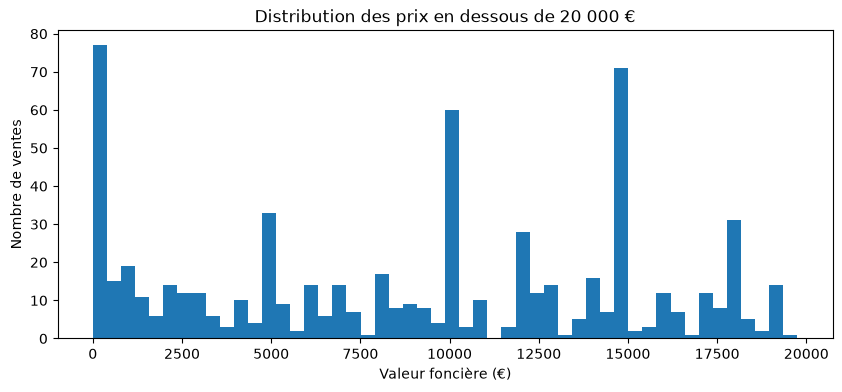

In [111]:
# Visualisation de la distribution des prix bas pour repérer une
# éventuelle coupure nette
plt.figure(figsize=(10, 4))
plt.hist(df[df["valeur_fonciere"] < 20000]["valeur_fonciere"], bins=50)
plt.xlabel("Valeur foncière (€)")
plt.ylabel("Nombre de ventes")
plt.title("Distribution des prix en dessous de 20 000 €")
plt.show()

**Résultat :** aucune coupure nette sur le prix brut, avec même des pics suspects sur des montants ronds (5000€, 10000€, 15000€...), possiblement des ventes de parts de propriété plutôt que du bien entier. Le prix brut seul n'est pas une mesure fiable pour juger ce qui est aberrant : on passe au prix au m², qui neutralise l'effet de la taille du bien.

In [112]:
# Calcul du prix au m² pour chaque vente
df["prix_m2"] = df["valeur_fonciere"] / df["surface_reelle_bati"]

df["prix_m2"].describe()

count     79338.000000
mean       3003.994511
std        2738.824299
min           0.004310
25%        1951.219512
50%        2714.285714
75%        3671.714796
max      465585.000000
Name: prix_m2, dtype: float64

In [113]:
# Les 20 ventes les moins chères au m²
df.sort_values("prix_m2").head(20)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
67261,2025-454014,2025-03-14,2025,1.0,232.0,Maison,35049,Cancale,-1.855914,48.674698,0.004310
63662,2024-442800,2024-12-12,2024,1.0,180.0,Maison,35212,Pancé,NaN,NaN,0.005556
31952,2022-602552,2022-10-21,2022,1.0,174.0,Maison,35019,Bazouges-la-Pérouse,-1.575254,48.427634,0.005747
47108,2023-488429,2023-09-13,2023,1.0,172.0,Maison,35093,Dinard,-2.052618,48.633978,0.005814
17251,2021-620544,2021-12-10,2021,1.0,157.0,Maison,35288,Saint-Malo,-1.976340,48.669772,0.006369
34425,2022-607653,2022-12-20,2022,1.0,152.0,Maison,35068,Châteaubourg,NaN,NaN,0.006579
22295,2022-586991,2022-03-29,2022,1.0,149.0,Maison,35069,Châteaugiron,-1.504098,48.045876,0.006711
77437,2025-469661,2025-10-29,2025,1.0,134.0,Maison,35297,Saint-Méen-le-Grand,-2.192588,48.189333,0.007463
60628,2024-437755,2024-09-27,2024,1.0,133.0,Maison,35219,Pipriac,-1.946301,47.807982,0.007519
69221,2025-457106,2025-04-25,2025,1.0,130.0,Appartement,35184,Montauban-de-Bretagne,-2.047674,48.200648,0.007692


**Résultat :** une fois rapporté à la surface, le bas du classement est occupé uniquement par les ventes à 1€ pile, plus nettement que sur le prix brut.

In [114]:
# Tentative de bornes statistiques (IQR) sur le prix au m², hors ventes
# à 1€, pour voir si la méthode devient exploitable des deux côtés
df_sans_1euro = df[df["valeur_fonciere"] > 1]

q1 = df_sans_1euro["prix_m2"].quantile(0.25)
q3 = df_sans_1euro["prix_m2"].quantile(0.75)
iqr = q3 - q1

borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr

print("Q1 :", q1)
print("Q3 :", q3)
print("Borne basse :", borne_basse)
print("Borne haute :", borne_haute)

Q1 : 1952.894858730894
Q3 : 3672.386781609195
Borne basse : -626.343025586558
Borne haute : 6251.624665926647


**Résultat :** la borne haute (6252€/m²) est exploitable, mais la borne basse reste négative : la méthode IQR classique ne fonctionne pas nativement sur une distribution de prix non négative et asymétrique.

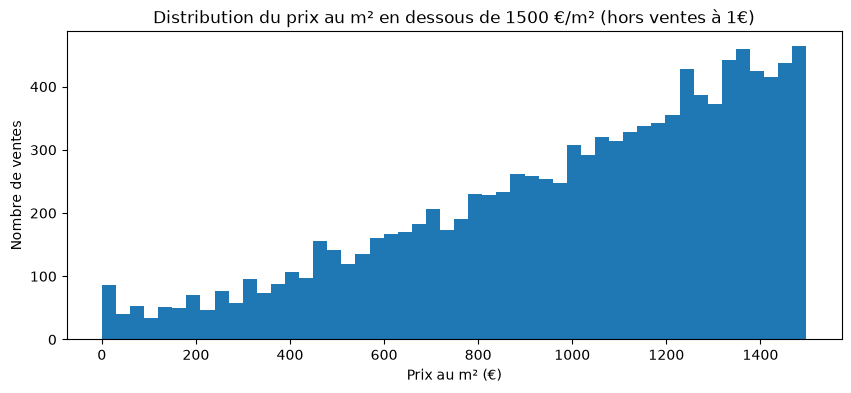

In [115]:
# Vérification par histogramme si une coupure naturelle existe malgré
# tout dans le bas de la distribution, une fois le 1€ exclu
plt.figure(figsize=(10, 4))
plt.hist(df_sans_1euro[df_sans_1euro["prix_m2"] < 1500]["prix_m2"], bins=50)
plt.xlabel("Prix au m² (€)")
plt.ylabel("Nombre de ventes")
plt.title("Distribution du prix au m² en dessous de 1500 €/m² (hors ventes à 1€)")
plt.show()

**Résultat :** aucune coupure nette, croissance continue depuis presque 0. Ces petits prix reflètent vraisemblablement de vraies communes rurales moins chères du département, pas des erreurs.

In [116]:
# Application des filtres retenus : exclusion des ventes à 1€ (prix
# symbolique) et des prix au m² au-dessus de la borne IQR haute
df = df[df["valeur_fonciere"] > 1]
df = df[df["prix_m2"] <= 6251.62]

print(df.shape)

(76533, 11)


In [117]:
# Vérification des plus petites surfaces
df.sort_values("surface_reelle_bati").head(15)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
45917,2023-486663,2023-08-23,2023,13000.0,7.0,Appartement,35125,La Guerche-de-Bretagne,-1.226294,47.941052,1857.142857
2118,2021-594669,2021-05-21,2021,43800.0,8.0,Appartement,35238,Rennes,-1.665042,48.117394,5475.000000
24023,2022-589939,2022-06-21,2022,18000.0,8.0,Appartement,35238,Rennes,-1.675680,48.109527,2250.000000
40654,2023-478082,2023-03-27,2023,27000.0,8.0,Appartement,35238,Rennes,-1.683484,48.109679,3375.000000
55166,2024-429346,2024-04-29,2024,41000.0,9.0,Appartement,35238,Rennes,-1.697374,48.116447,4555.555556
74187,2025-464463,2025-09-02,2025,35000.0,9.0,Appartement,35238,Rennes,-1.697374,48.116447,3888.888889
25364,2022-592105,2022-06-21,2022,45000.0,9.0,Appartement,35238,Rennes,-1.697374,48.116447,5000.000000
52826,2024-425381,2024-02-15,2024,45500.0,9.0,Appartement,35238,Rennes,-1.697374,48.116447,5055.555556
39215,2023-475640,2023-03-06,2023,45000.0,9.0,Appartement,35238,Rennes,-1.686391,48.107939,5000.000000
4702,2021-598391,2021-09-10,2021,51000.0,9.0,Appartement,35238,Rennes,-1.697374,48.116447,5666.666667


**Résultat :** des appartements de 7 à 9m² à Rennes, avec des prix cohérents : probablement de vrais micro-studios ou chambres de service, rien à exclure.

In [118]:
# Vérification des plus grandes surfaces
df.sort_values("surface_reelle_bati", ascending=False).head(15)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
61647,2024-439394,2024-10-30,2024,215234.83,1360.0,Appartement,35288,Saint-Malo,NaN,NaN,158.260904
36998,2023-471801,2023-01-06,2023,300.00,1225.0,Appartement,35238,Rennes,-1.662969,48.125364,0.244898
22063,2022-586594,2022-04-26,2022,900000.00,1158.0,Maison,35238,Rennes,-1.656910,48.127068,777.202073
76625,2025-468349,2025-10-07,2025,265000.00,1072.0,Maison,35207,Noyal-sur-Vilaine,-1.518933,48.115160,247.201493
51100,2023-495564,2023-12-18,2023,5100000.00,982.0,Appartement,35281,Saint-Jacques-de-la-Lande,-1.718967,48.063780,5193.482688
10341,2021-608468,2021-06-25,2021,875000.00,889.0,Maison,35197,Mouazé,-1.599967,48.229673,984.251969
44746,2023-484859,2023-07-05,2023,181170.00,729.0,Appartement,35206,Noyal-Châtillon-sur-Seiche,-1.672727,48.039355,248.518519
37625,2023-472882,2023-01-20,2023,1900000.00,702.0,Maison,35093,Dinard,-2.061936,48.638298,2706.552707
70125,2025-458560,2025-05-28,2025,1500000.00,634.0,Maison,35210,Pacé,-1.796827,48.135976,2365.930599
11465,2021-610436,2021-08-18,2021,1595000.00,622.0,Maison,35257,Maen Roch,-1.349382,48.408009,2564.308682


In [119]:
# Zoom sur les grands appartements (>300m²), où la plupart des prix au
# m² restent cohérents, sauf un ou deux cas à vérifier
df[(df["type_local"] == "Appartement") & (df["surface_reelle_bati"] > 300)].sort_values("surface_reelle_bati", ascending=False)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
61647,2024-439394,2024-10-30,2024,215234.83,1360.0,Appartement,35288,Saint-Malo,NaN,NaN,158.260904
36998,2023-471801,2023-01-06,2023,300.00,1225.0,Appartement,35238,Rennes,-1.662969,48.125364,0.244898
51100,2023-495564,2023-12-18,2023,5100000.00,982.0,Appartement,35281,Saint-Jacques-de-la-Lande,-1.718967,48.063780,5193.482688
44746,2023-484859,2023-07-05,2023,181170.00,729.0,Appartement,35206,Noyal-Châtillon-sur-Seiche,-1.672727,48.039355,248.518519
9302,2021-606461,2021-08-26,2021,885000.00,561.0,Appartement,35327,Servon-sur-Vilaine,-1.465305,48.115203,1577.540107
10019,2021-607806,2021-11-17,2021,698902.25,556.0,Appartement,35076,Chavagne,-1.789581,48.051895,1257.018435
58571,2024-434776,2024-07-30,2024,1440000.00,551.0,Appartement,35238,Rennes,-1.679649,48.114674,2613.430127
49842,2023-493169,2023-11-16,2023,2150000.00,549.0,Appartement,35238,Rennes,-1.676721,48.103699,3916.211293
8619,2021-605451,2021-07-07,2021,675000.00,521.0,Appartement,35128,Guipel,-1.719363,48.300394,1295.585413
42356,2023-480906,2023-05-30,2023,500000.00,520.0,Appartement,35178,Mézières-sur-Couesnon,-1.433329,48.307971,961.538462


**Résultat :** deux cas à prix quasi nul repérés (1225m² à 300€, 401m² à 100€), le même phénomène de prix symbolique que le 1€ mais avec un montant différent. Notre filtre initial était trop étroit.

In [120]:
# Élargissement du filtre sur le prix au m² très bas, pour attraper ces
# cas symboliques quel que soit leur montant exact
(df["prix_m2"] < 50).sum()

np.int64(113)

In [121]:
# Vérification des lignes les plus proches du seuil de 50€/m², pour
# s'assurer qu'on n'exclurait pas de vraies petites ventes rurales
# légitimes
df[df["prix_m2"] < 50].sort_values("prix_m2", ascending=False).head(15)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
61403,2024-439014,2024-09-26,2024,8015.92,161.0,Maison,35337,Tinténiac,-1.810946,48.297282,49.788323
24576,2022-590842,2022-06-09,2022,6000.00,122.0,Appartement,35128,Guipel,-1.723163,48.298398,49.180328
1730,2021-594114,2021-04-26,2021,2350.00,50.0,Appartement,35238,Rennes,-1.688284,48.118981,47.000000
23754,2022-589466,2022-06-08,2022,750.00,16.0,Appartement,35238,Rennes,-1.684333,48.111338,46.875000
1760,2021-594163,2021-04-28,2021,4000.00,86.0,Appartement,35238,Rennes,-1.685998,48.106824,46.511628
12598,2021-612451,2021-05-07,2021,5000.00,111.0,Maison,35236,Redon,NaN,NaN,45.045045
11851,2021-611061,2021-11-26,2021,6000.00,134.0,Maison,35004,Val-Couesnon,-1.466567,48.451488,44.776119
18700,2021-623057,2021-10-01,2021,12462.00,284.0,Maison,35014,Bais,NaN,NaN,43.880282
65180,2025-450675,2025-01-20,2025,2500.00,57.0,Appartement,35238,Rennes,-1.682100,48.110317,43.859649
17454,2021-620952,2021-12-21,2021,5500.00,126.0,Maison,35222,Pleine-Fougères,-1.535769,48.550594,43.650794


**Résultat :** même les cas les plus proches de 50€/m² restent clairement des prix symboliques (ex. 122m² à Guipel pour 6000€). Seuil validé.

In [122]:
# Application du filtre affiné sur le prix au m² (remplace le filtre
# initial sur le 1€ seul)
df = df[df["prix_m2"] >= 50]

print(df.shape)

(76420, 11)


In [123]:
# Nouvelle vérification des grands appartements après ce filtrage
df[(df["type_local"] == "Appartement") & (df["surface_reelle_bati"] > 300)].sort_values("surface_reelle_bati", ascending=False)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
61647,2024-439394,2024-10-30,2024,215234.83,1360.0,Appartement,35288,Saint-Malo,NaN,NaN,158.260904
51100,2023-495564,2023-12-18,2023,5100000.00,982.0,Appartement,35281,Saint-Jacques-de-la-Lande,-1.718967,48.063780,5193.482688
44746,2023-484859,2023-07-05,2023,181170.00,729.0,Appartement,35206,Noyal-Châtillon-sur-Seiche,-1.672727,48.039355,248.518519
9302,2021-606461,2021-08-26,2021,885000.00,561.0,Appartement,35327,Servon-sur-Vilaine,-1.465305,48.115203,1577.540107
10019,2021-607806,2021-11-17,2021,698902.25,556.0,Appartement,35076,Chavagne,-1.789581,48.051895,1257.018435
58571,2024-434776,2024-07-30,2024,1440000.00,551.0,Appartement,35238,Rennes,-1.679649,48.114674,2613.430127
49842,2023-493169,2023-11-16,2023,2150000.00,549.0,Appartement,35238,Rennes,-1.676721,48.103699,3916.211293
8619,2021-605451,2021-07-07,2021,675000.00,521.0,Appartement,35128,Guipel,-1.719363,48.300394,1295.585413
42356,2023-480906,2023-05-30,2023,500000.00,520.0,Appartement,35178,Mézières-sur-Couesnon,-1.433329,48.307971,961.538462
74338,2025-464684,2025-09-16,2025,2519000.00,509.0,Appartement,35059,La Chapelle-des-Fougeretz,-1.732642,48.178222,4948.919450


**Résultat :** les deux cas à prix quasi nul ont disparu. Un cas isolé résiste encore : un "Appartement" de 1360m² à Saint-Malo à 158€/m², avec un saut net par rapport au 2e plus grand appartement (982m²). Probable immeuble entier enregistré comme un seul appartement.

In [124]:
# Vérification symétrique côté maisons, pour ne pas fixer un seuil
# uniquement du côté appartement sans avoir contrôlé l'autre catégorie
df[df["type_local"] == "Maison"].sort_values("surface_reelle_bati", ascending=False).head(10)

,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
22063,2022-586594,2022-04-26,2022,900000.0,1158.0,Maison,35238,Rennes,-1.656910,48.127068,777.202073
76625,2025-468349,2025-10-07,2025,265000.0,1072.0,Maison,35207,Noyal-sur-Vilaine,-1.518933,48.115160,247.201493
10341,2021-608468,2021-06-25,2021,875000.0,889.0,Maison,35197,Mouazé,-1.599967,48.229673,984.251969
37625,2023-472882,2023-01-20,2023,1900000.0,702.0,Maison,35093,Dinard,-2.061936,48.638298,2706.552707
70125,2025-458560,2025-05-28,2025,1500000.0,634.0,Maison,35210,Pacé,-1.796827,48.135976,2365.930599
11465,2021-610436,2021-08-18,2021,1595000.0,622.0,Maison,35257,Maen Roch,-1.349382,48.408009,2564.308682
54355,2024-427998,2024-03-28,2024,177000.0,616.0,Maison,35104,Epiniac,-1.698592,48.513595,287.337662
16235,2021-618827,2021-08-27,2021,1555000.0,577.0,Maison,35288,Saint-Malo,-1.993957,48.608992,2694.974003
37887,2023-473365,2023-01-30,2023,555000.0,548.0,Maison,35360,Vitré,-1.192066,48.097995,1012.773723
35584,2022-610067,2022-02-04,2022,780000.0,546.0,Maison,35115,Fougères,-1.203794,48.346960,1428.571429


**Résultat :** progression régulière côté maisons, prix au m² cohérents avec la localisation à chaque fois. Aucune anomalie détectée, rien à exclure.

In [125]:
# Exclusion ciblée du seul cas isolé d'appartement à surface excessive,
# sans toucher aux autres grands appartements légitimes
df = df[~((df["type_local"] == "Appartement") & (df["surface_reelle_bati"] > 1000))]

print(df.shape)

(76419, 11)


## 8. Vérification finale et export

Dernier contrôle de cohérence avant d'exporter le jeu de données nettoyé, qui servira de point de départ au notebook `02_analyse_exploratoire.ipynb`.

In [126]:
# Contrôle final : nombre de lignes, valeurs manquantes restantes,
# statistiques descriptives sur les colonnes clés
print("Nombre de lignes :", len(df))
print()
print("Valeurs manquantes restantes :")
print(df.isnull().sum())
print()
print(df[["valeur_fonciere", "surface_reelle_bati", "prix_m2"]].describe())

Nombre de lignes : 76419

Valeurs manquantes restantes :
id_mutation              0
date_mutation            0
annee                    0
valeur_fonciere          0
surface_reelle_bati      0
type_local               0
code_commune             0
nom_commune              0
longitude              956
latitude               956
prix_m2                  0
dtype: int64

       valeur_fonciere  surface_reelle_bati       prix_m2
count     7.641900e+04         76419.000000  76419.000000
mean      2.317549e+05            88.947578   2787.006532
std       1.480470e+05            46.566157   1231.310882
min       1.000000e+03             7.000000     50.505051
25%       1.400000e+05            60.000000   1928.571429
50%       2.000000e+05            81.000000   2666.666667
75%       2.885000e+05           111.000000   3541.666667
max       5.100000e+06          1158.000000   6250.961538


**Résultat :** plus aucune valeur manquante sur les colonnes essentielles. Seules `longitude`/`latitude` gardent 956 valeurs manquantes, sans impact sur les 5 questions business ni sur la carte choroplèthe prévue (travail au niveau commune, pas au point individuel). Statistiques cohérentes avec un vrai marché immobilier.

In [127]:
# Export du jeu de données nettoyé, réutilisé par le notebook suivant
df.to_csv("../data/cleaned/dvf_35_nettoye.csv", index=False)

print("Export terminé :", df.shape)

Export terminé : (76419, 11)
